# 📊 Análise Diagnóstica da Queda no Faturamento

## Objetivo
Identificar as causas da redução no faturamento de vendas.

## Problema
Queda no valor total vendido, mesmo com variações no mix de produtos.

## Hipótese
Aumento no preço médio pode ter reduzido o volume de compras.

  

1. Descrição das variáveis contidas no conjunto de dados

- **ID_VENDA**: Identificador único da venda  
- **ID_PRODUTO**: Identificador do produto  
- **CANAL_VENDA**: Canal utilizado para a venda (neste caso, sempre "E-Commerce")  
- **NOME_PRODUTO**: Nome do produto vendido (Mouse, Teclado, etc.)  
- **DATA_COMPRA**: Data em que a compra foi realizada  
- **VALOR_COMPRA**: Valor de custo do produto para a empresa  
- **MARGEM_LUCRO**: Margem de lucro aplicada sobre o valor de compra  
- **VALOR_VENDA**: Preço final de venda do produto  
- **UF_VENDA**: Estado da federação onde ocorreu a venda  
- **QT_VENDA**: Quantidade de produtos vendidos naquela venda  
- **TOTAL_VENDA**: Valor total da venda (VALOR_VENDA * QT_VENDA)  
- **LUCRO_POR_PRODUTO**: Lucro individual por item vendido  
- **TOTAL_LUCRO**: Lucro total da venda (LUCRO_POR_PRODUTO * QT_VENDA)

2. Importação de Bibliotecas

In [45]:

# Impotando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ruptures
import ruptures as rpt

pd.set_option('display.max_columns', None)

3. Carregamento dos Dados

In [46]:
# Carregar os Dados
df = pd.read_excel('vendas_2024.xlsx')

In [47]:
# Dimensão do conjunto de dados
df.shape

(20000, 13)

In [48]:
df.head()

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO
0,1,3216,E-Commerce,Memória RAM 128Gb,2024-07-05,950.0,0.65,1567.5,RS,8.0,12540.0,617.5,4940.0
1,2,1383,E-Commerce,Monitor,2024-01-23,900.0,0.65,1485.0,PE,8.0,11880.0,585.0,4680.0
2,3,1383,E-Commerce,Monitor,2024-01-31,900.0,0.65,1485.0,AP,7.0,10395.0,585.0,4095.0
3,4,3216,E-Commerce,Memória RAM 128Gb,2024-01-06,950.0,0.65,1567.5,AL,4.0,6270.0,617.5,2470.0
4,5,5274,E-Commerce,Memória RAM 256Gb,2024-03-31,1800.0,0.65,2970.0,PI,NaN,20790.0,1170.0,8190.0


4. Tratamento de Dados

In [49]:
# Verificando os produtos
df['NOME_PRODUTO'].unique()

array(['Memória RAM 128Gb', 'Monitor', 'Memória RAM 256Gb', 'Teclado',
       'Mouse'], dtype=object)

In [50]:

# Verificando os tipo de cada variável
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID_VENDA           20000 non-null  int64         
 1   ID_PRODUTO         20000 non-null  int64         
 2   CANAL_VENDA        20000 non-null  object        
 3   NOME_PRODUTO       20000 non-null  object        
 4   DATA_COMPRA        20000 non-null  datetime64[ns]
 5   VALOR_COMPRA       19800 non-null  float64       
 6   MARGEM_LUCRO       20000 non-null  float64       
 7   VALOR_VENDA        20000 non-null  float64       
 8   UF_VENDA           19800 non-null  object        
 9   QT_VENDA           19800 non-null  float64       
 10  TOTAL_VENDA        19930 non-null  float64       
 11  LUCRO_POR_PRODUTO  20000 non-null  float64       
 12  TOTAL_LUCRO        19930 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(2), object(3)
memory 

In [51]:

# Verificando se tem valores nulos

df.isnull().sum()

,0
ID_VENDA,0
ID_PRODUTO,0
CANAL_VENDA,0
NOME_PRODUTO,0
DATA_COMPRA,0
VALOR_COMPRA,200
MARGEM_LUCRO,0
VALOR_VENDA,0
UF_VENDA,200
QT_VENDA,200


In [52]:

# Somando os valores nulos

df.isnull().sum().sum()

np.int64(740)

In [53]:

# Verificando o percentual de valores nulos em relação ao total de registros
(df.isnull().sum().sum() / len(df)) * 100

np.float64(3.6999999999999997)

In [54]:

# Verificando os resgistro das colunas com valores nulos
df[df['VALOR_COMPRA'].isnull()]

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO
188,189,1383,E-Commerce,Monitor,2024-08-25,NaN,0.65,1485.00,RN,6.0,8910.00,585.00,3510.00
320,321,4523,E-Commerce,Mouse,2024-09-07,NaN,0.65,175.56,MS,3.0,526.68,69.16,207.48
351,352,3216,E-Commerce,Memória RAM 128Gb,2024-01-12,NaN,0.65,1567.50,MT,4.0,6270.00,617.50,2470.00
463,464,1488,E-Commerce,Teclado,2024-10-01,NaN,0.65,263.34,PB,5.0,1316.70,103.74,518.70
531,532,1383,E-Commerce,Monitor,2024-07-06,NaN,0.65,1485.00,PE,3.0,4455.00,585.00,1755.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19631,19632,1488,E-Commerce,Teclado,2024-03-15,NaN,0.65,198.00,AC,7.0,1386.00,78.00,546.00
19632,19633,1488,E-Commerce,Teclado,2024-05-25,NaN,0.65,198.00,DF,5.0,990.00,78.00,390.00
19847,19848,4523,E-Commerce,Mouse,2024-06-18,NaN,0.65,132.00,SE,8.0,1056.00,52.00,416.00
19881,19882,3216,E-Commerce,Memória RAM 128Gb,2024-05-12,NaN,0.65,1567.50,ES,6.0,9405.00,617.50,3705.00


In [55]:

# Verificando QT_VENDA

df[df['QT_VENDA'].isnull()]

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO
4,5,5274,E-Commerce,Memória RAM 256Gb,2024-03-31,1800.0,0.65,2970.00,PI,NaN,20790.0,1170.00,8190.0
67,68,3216,E-Commerce,Memória RAM 128Gb,2024-03-04,950.0,0.65,1567.50,PA,NaN,7837.5,617.50,3087.5
254,255,3216,E-Commerce,Memória RAM 128Gb,2024-03-14,950.0,0.65,1567.50,AP,NaN,14107.5,617.50,5557.5
343,344,5274,E-Commerce,Memória RAM 256Gb,2024-08-15,1800.0,0.65,2970.00,RJ,NaN,23760.0,1170.00,9360.0
499,500,4523,E-Commerce,Mouse,2024-11-11,106.4,0.65,175.56,MG,NaN,NaN,69.16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19630,19631,3216,E-Commerce,Memória RAM 128Gb,2024-07-12,950.0,0.65,1567.50,SE,NaN,3135.0,617.50,1235.0
19639,19640,1383,E-Commerce,Monitor,2024-07-26,900.0,0.65,1485.00,ES,NaN,4455.0,585.00,1755.0
19761,19762,5274,E-Commerce,Memória RAM 256Gb,2024-03-14,1800.0,0.65,2970.00,PI,NaN,26730.0,1170.00,10530.0
19811,19812,1383,E-Commerce,Monitor,2024-02-01,900.0,0.65,1485.00,SP,NaN,14850.0,585.00,5850.0


In [56]:

# Verificando TOTAL_VENDA

df[df['TOTAL_VENDA'].isnull()]

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO
499,500,4523,E-Commerce,Mouse,2024-11-11,106.4,0.65,175.56,MG,NaN,NaN,69.16,NaN
1079,1080,1383,E-Commerce,Monitor,2024-09-23,1197.0,0.65,1975.05,TO,NaN,NaN,778.05,NaN
2136,2137,5274,E-Commerce,Memória RAM 256Gb,2024-10-17,2394.0,0.65,3950.10,AM,NaN,NaN,1556.10,NaN
2159,2160,5274,E-Commerce,Memória RAM 256Gb,2024-09-22,2394.0,0.65,3950.10,AM,NaN,NaN,1556.10,NaN
2312,2313,1383,E-Commerce,Monitor,2024-12-07,1197.0,0.65,1975.05,MA,NaN,NaN,778.05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18467,18468,4523,E-Commerce,Mouse,2024-12-13,106.4,0.65,175.56,TO,NaN,NaN,69.16,NaN
18983,18984,4523,E-Commerce,Mouse,2024-09-10,106.4,0.65,175.56,RO,NaN,NaN,69.16,NaN
19488,19489,4523,E-Commerce,Mouse,2024-12-05,106.4,0.65,175.56,MT,NaN,NaN,69.16,NaN
19531,19532,1488,E-Commerce,Teclado,2024-10-06,159.6,0.65,263.34,DF,NaN,NaN,103.74,NaN


In [57]:

# Verificando TOTAL_LUCRO

df[df['TOTAL_LUCRO'].isnull()]

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO
499,500,4523,E-Commerce,Mouse,2024-11-11,106.4,0.65,175.56,MG,NaN,NaN,69.16,NaN
1079,1080,1383,E-Commerce,Monitor,2024-09-23,1197.0,0.65,1975.05,TO,NaN,NaN,778.05,NaN
2136,2137,5274,E-Commerce,Memória RAM 256Gb,2024-10-17,2394.0,0.65,3950.10,AM,NaN,NaN,1556.10,NaN
2159,2160,5274,E-Commerce,Memória RAM 256Gb,2024-09-22,2394.0,0.65,3950.10,AM,NaN,NaN,1556.10,NaN
2312,2313,1383,E-Commerce,Monitor,2024-12-07,1197.0,0.65,1975.05,MA,NaN,NaN,778.05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18467,18468,4523,E-Commerce,Mouse,2024-12-13,106.4,0.65,175.56,TO,NaN,NaN,69.16,NaN
18983,18984,4523,E-Commerce,Mouse,2024-09-10,106.4,0.65,175.56,RO,NaN,NaN,69.16,NaN
19488,19489,4523,E-Commerce,Mouse,2024-12-05,106.4,0.65,175.56,MT,NaN,NaN,69.16,NaN
19531,19532,1488,E-Commerce,Teclado,2024-10-06,159.6,0.65,263.34,DF,NaN,NaN,103.74,NaN


In [58]:

# preencher VALOR_COMPRA apenas quando VALOR_VENDA e MARGEM_LUCRO estiverem disponíveis

mascara = df['VALOR_COMPRA'].isnull() & df['VALOR_VENDA'].notnull() & df['MARGEM_LUCRO'].notnull()

# Aplincando somente nas linhas com dados válidos

df.loc[mascara, 'VALOR_COMPRA'] = df.loc[mascara, 'VALOR_VENDA'] / (1 + df.loc[mascara, 'MARGEM_LUCRO'])

In [59]:

# Preencher QT_VENDA apenas quando TOTAL_VENDA e VALOR_VENDA estiverem com valores

mascara = df['QT_VENDA'].isnull() & df['VALOR_VENDA'].notnull() & df['TOTAL_VENDA'].notnull()


# Aplicar cálculo seguro somente nas linhas com dados válidos

df.loc[mascara, 'QT_VENDA'] = df.loc[mascara, 'TOTAL_VENDA'] / (df.loc[mascara, 'VALOR_VENDA'])

In [60]:
df.isnull().sum()

,0
ID_VENDA,0
ID_PRODUTO,0
CANAL_VENDA,0
NOME_PRODUTO,0
DATA_COMPRA,0
VALOR_COMPRA,0
MARGEM_LUCRO,0
VALOR_VENDA,0
UF_VENDA,200
QT_VENDA,70


In [61]:

# Verificando ses conseguimos ajustar mais casos da variável QT_VENDA

df[df['QT_VENDA'].isnull() & df['VALOR_VENDA'].notnull() & df['TOTAL_VENDA'].notnull()]

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO


In [62]:

# Verificando ses conseguimos ajustar o TOTAL_VENDA e TOTAL_LUCRO

df[df['TOTAL_VENDA'].isnull() & df['QT_VENDA'].notnull() & df['VALOR_VENDA'].notnull()]


,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO


In [63]:
df.head()

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO
0,1,3216,E-Commerce,Memória RAM 128Gb,2024-07-05,950.0,0.65,1567.5,RS,8.0,12540.0,617.5,4940.0
1,2,1383,E-Commerce,Monitor,2024-01-23,900.0,0.65,1485.0,PE,8.0,11880.0,585.0,4680.0
2,3,1383,E-Commerce,Monitor,2024-01-31,900.0,0.65,1485.0,AP,7.0,10395.0,585.0,4095.0
3,4,3216,E-Commerce,Memória RAM 128Gb,2024-01-06,950.0,0.65,1567.5,AL,4.0,6270.0,617.5,2470.0
4,5,5274,E-Commerce,Memória RAM 256Gb,2024-03-31,1800.0,0.65,2970.0,PI,7.0,20790.0,1170.0,8190.0


In [64]:
df['QT_VENDA'] = df['QT_VENDA'].round().astype('Int64')

In [65]:

#Agora podemos remover os que restaram

print("Registros com valores nulos:", df.isnull().any(axis=1).sum())

Registros com valores nulos: 269


In [66]:

# Removedo as observações(linhas) que estão com valores nulos

df.dropna(inplace=True)

In [67]:

# Verificando se existe valores nulos

df.isnull().sum()

,0
ID_VENDA,0
ID_PRODUTO,0
CANAL_VENDA,0
NOME_PRODUTO,0
DATA_COMPRA,0
VALOR_COMPRA,0
MARGEM_LUCRO,0
VALOR_VENDA,0
UF_VENDA,0
QT_VENDA,0


5. Análise de valores do produtos

In [92]:

#Média do Valor de Compra pro Produto

df.groupby(['NOME_PRODUTO'])['VALOR_COMPRA'].mean()

,VALOR_COMPRA
NOME_PRODUTO,
Memória RAM 128Gb,1052.723951
Memória RAM 256Gb,1996.536324
Monitor,1000.809399
Mouse,88.902171
Teclado,132.821918


In [69]:

# Soma de quantidade de venda por produto

df.groupby('NOME_PRODUTO')['QT_VENDA'].sum()

,QT_VENDA
NOME_PRODUTO,
Memória RAM 128Gb,19142
Memória RAM 256Gb,18635
Monitor,18331
Mouse,18742
Teclado,19344


In [70]:
df.head()

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO
0,1,3216,E-Commerce,Memória RAM 128Gb,2024-07-05,950.0,0.65,1567.5,RS,8,12540.0,617.5,4940.0
1,2,1383,E-Commerce,Monitor,2024-01-23,900.0,0.65,1485.0,PE,8,11880.0,585.0,4680.0
2,3,1383,E-Commerce,Monitor,2024-01-31,900.0,0.65,1485.0,AP,7,10395.0,585.0,4095.0
3,4,3216,E-Commerce,Memória RAM 128Gb,2024-01-06,950.0,0.65,1567.5,AL,4,6270.0,617.5,2470.0
4,5,5274,E-Commerce,Memória RAM 256Gb,2024-03-31,1800.0,0.65,2970.0,PI,7,20790.0,1170.0,8190.0


In [71]:

# Criar uma nova variável mes_ano

df['MES_ANO'] = df['DATA_COMPRA'].dt.to_period('M')

In [72]:
df.head()

,ID_VENDA,ID_PRODUTO,CANAL_VENDA,NOME_PRODUTO,DATA_COMPRA,VALOR_COMPRA,MARGEM_LUCRO,VALOR_VENDA,UF_VENDA,QT_VENDA,TOTAL_VENDA,LUCRO_POR_PRODUTO,TOTAL_LUCRO,MES_ANO
0,1,3216,E-Commerce,Memória RAM 128Gb,2024-07-05,950.0,0.65,1567.5,RS,8,12540.0,617.5,4940.0,2024-07
1,2,1383,E-Commerce,Monitor,2024-01-23,900.0,0.65,1485.0,PE,8,11880.0,585.0,4680.0,2024-01
2,3,1383,E-Commerce,Monitor,2024-01-31,900.0,0.65,1485.0,AP,7,10395.0,585.0,4095.0,2024-01
3,4,3216,E-Commerce,Memória RAM 128Gb,2024-01-06,950.0,0.65,1567.5,AL,4,6270.0,617.5,2470.0,2024-01
4,5,5274,E-Commerce,Memória RAM 256Gb,2024-03-31,1800.0,0.65,2970.0,PI,7,20790.0,1170.0,8190.0,2024-03


In [73]:

# Agrupamento de Quantidade de Vendas por Mês e Produto

media_por_mes = df.groupby(['MES_ANO', 'NOME_PRODUTO'])['QT_VENDA'].mean().reset_index()
media_por_mes

,MES_ANO,NOME_PRODUTO,QT_VENDA
0,2024-01,Memória RAM 128Gb,5.302469
1,2024-01,Memória RAM 256Gb,5.431611
2,2024-01,Monitor,5.423423
3,2024-01,Mouse,5.435294
4,2024-01,Teclado,5.628169
5,2024-02,Memória RAM 128Gb,5.581325
6,2024-02,Memória RAM 256Gb,5.38535
7,2024-02,Monitor,5.672598
8,2024-02,Mouse,5.497024
9,2024-02,Teclado,5.660194


In [74]:

# Agrupamento de Quantidade de Vendas por Mês e Valor Compra

media_por_mes = df.groupby(['MES_ANO', 'NOME_PRODUTO'])['VALOR_COMPRA'].mean().reset_index()
media_por_mes

,MES_ANO,NOME_PRODUTO,VALOR_COMPRA
0,2024-01,Memória RAM 128Gb,950.000000
1,2024-01,Memória RAM 256Gb,1800.000000
2,2024-01,Monitor,900.000000
3,2024-01,Mouse,80.000000
4,2024-01,Teclado,120.000000
5,2024-02,Memória RAM 128Gb,950.000000
6,2024-02,Memória RAM 256Gb,1800.000000
7,2024-02,Monitor,900.000000
8,2024-02,Mouse,80.000000
9,2024-02,Teclado,120.000000


6. Visualizando a quantidade de vendas por período

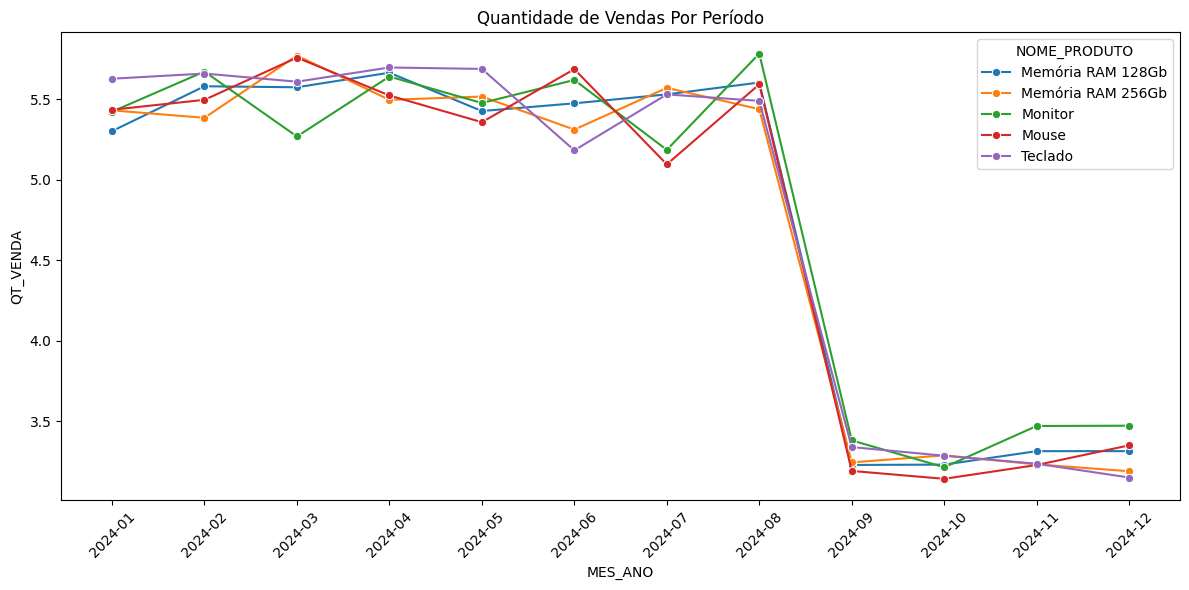

In [75]:

# Visualizar a quantidade de vendas por período
media_por_mes = df.groupby(['MES_ANO', 'NOME_PRODUTO'])['QT_VENDA'].mean().reset_index()

# Converter para string
media_por_mes['MES_ANO'] = media_por_mes['MES_ANO'].astype(str)

# Plotar
plt.figure(figsize=(12, 6))
sns.lineplot(data=media_por_mes, x='MES_ANO', y='QT_VENDA', hue='NOME_PRODUTO', marker='o')
plt.title('Quantidade de Vendas Por Período')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

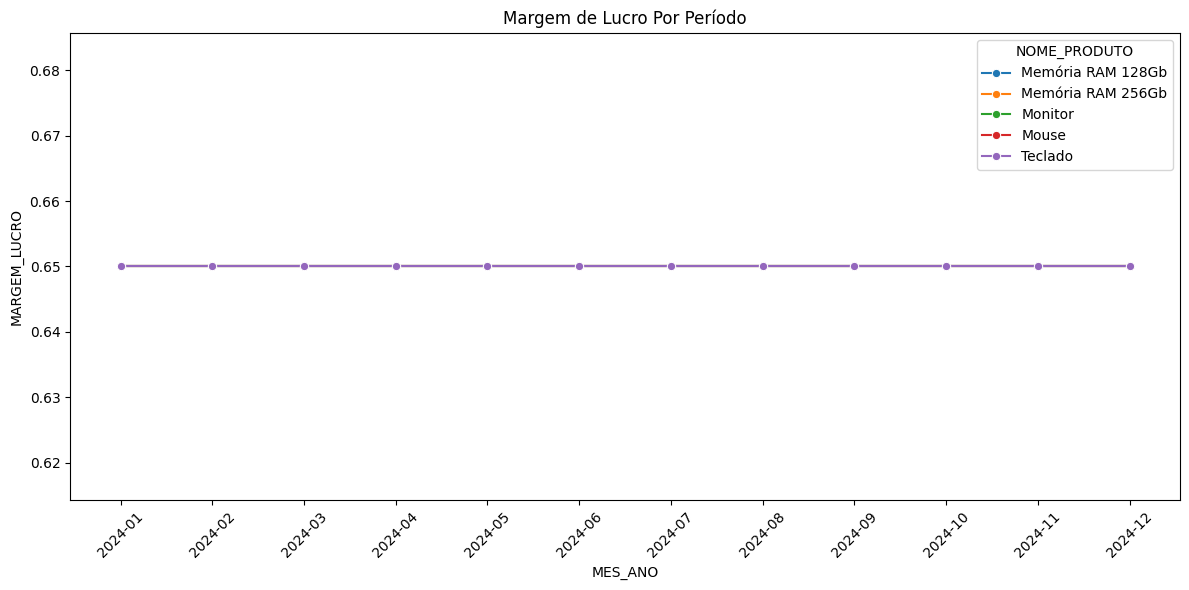

In [76]:
# Visualizar a margem de lucro por período
media_por_mes = df.groupby(['MES_ANO', 'NOME_PRODUTO'])['MARGEM_LUCRO'].mean().reset_index()

# Converter para string
media_por_mes['MES_ANO'] = media_por_mes['MES_ANO'].astype(str)

# Plotar
plt.figure(figsize=(12, 6))
sns.lineplot(data=media_por_mes, x='MES_ANO', y='MARGEM_LUCRO', hue='NOME_PRODUTO', marker='o')
plt.title('Margem de Lucro Por Período')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

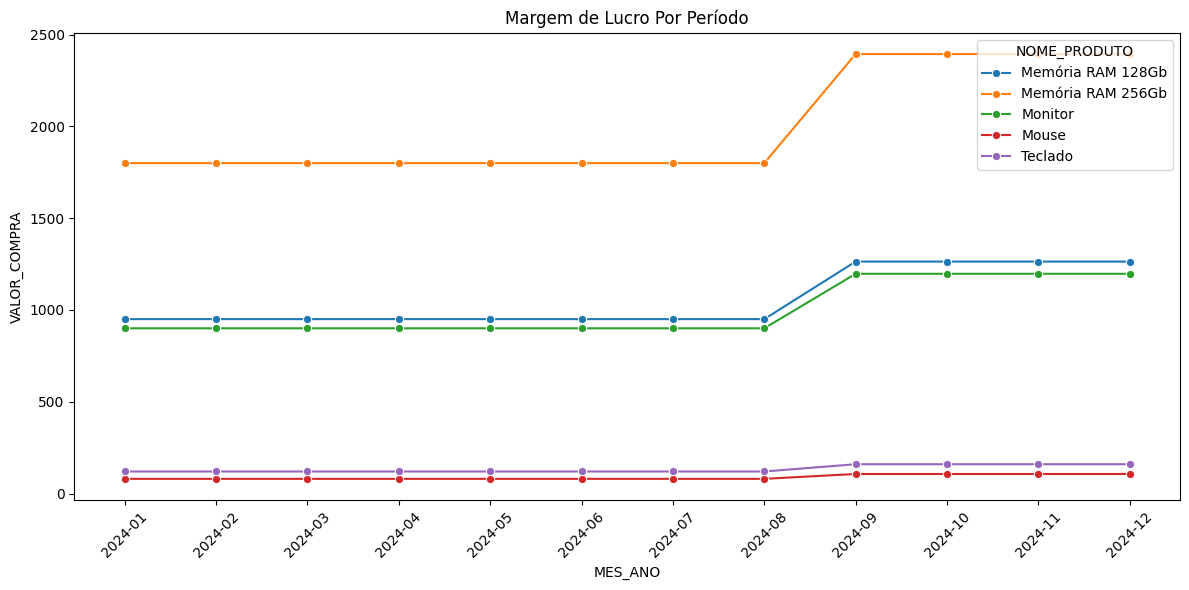

In [77]:
# Visualizar a quantidade de vendas por período
media_por_mes = df.groupby(['MES_ANO', 'NOME_PRODUTO'])['VALOR_COMPRA'].mean().reset_index()

# Converter para string
media_por_mes['MES_ANO'] = media_por_mes['MES_ANO'].astype(str)

# Plotar
plt.figure(figsize=(12, 6))
sns.lineplot(data=media_por_mes, x='MES_ANO', y='VALOR_COMPRA', hue='NOME_PRODUTO', marker='o')
plt.title('Margem de Lucro Por Período')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

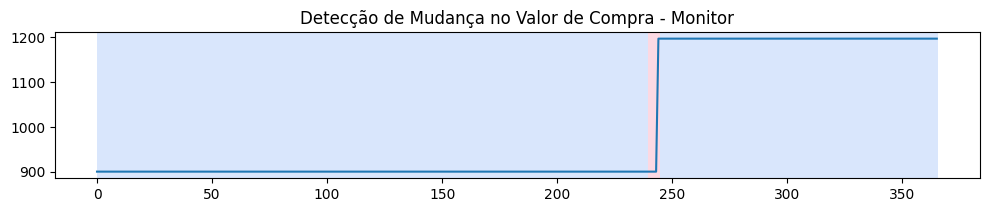

In [78]:
# Produto - Monitor
produto_df = df[df['NOME_PRODUTO'] == 'Monitor']
serie = produto_df.groupby(df['DATA_COMPRA'].dt.to_period('D'))['VALOR_COMPRA'].mean().dropna().values

# Algoritmo de detecção de mudança
model = "l2"  # mudança na média
algo = rpt.Pelt(model=model).fit(serie)
result = algo.predict(pen=5)  # penalidade controla sensibilidade

# Visualizar
rpt.display(serie, result)
plt.title('Detecção de Mudança no Valor de Compra - Monitor')
plt.show()

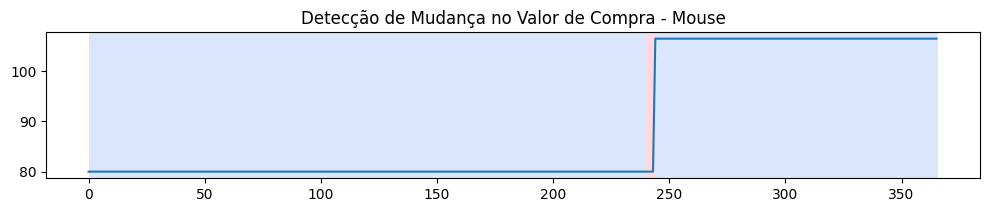

In [79]:
# Produto - Mouse
produto_df = df[df['NOME_PRODUTO'] == 'Mouse']
serie = produto_df.groupby(df['DATA_COMPRA'].dt.to_period('D'))['VALOR_COMPRA'].mean().dropna().values

# Algoritmo de detecção de mudança
model = "l2"  # mudança na média
algo = rpt.Pelt(model=model).fit(serie)
result = algo.predict(pen=5)  # penalidade controla sensibilidade

# Visualizar
rpt.display(serie, result)
plt.title('Detecção de Mudança no Valor de Compra - Mouse')
plt.show()

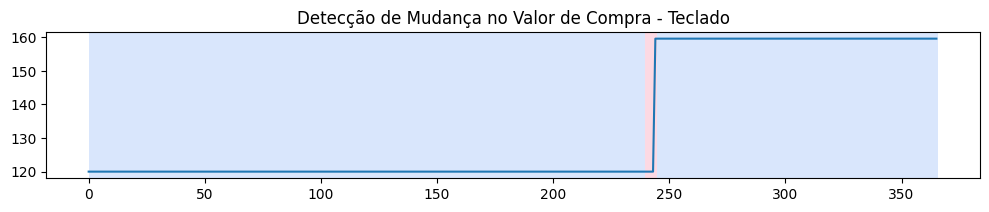

In [80]:
# Produto - Teclado
produto_df = df[df['NOME_PRODUTO'] == 'Teclado']
serie = produto_df.groupby(df['DATA_COMPRA'].dt.to_period('D'))['VALOR_COMPRA'].mean().dropna().values

# Algoritmo de detecção de mudança
model = "l2"  # mudança na média
algo = rpt.Pelt(model=model).fit(serie)
result = algo.predict(pen=5)  # penalidade controla sensibilidade

# Visualizar
rpt.display(serie, result)
plt.title('Detecção de Mudança no Valor de Compra - Teclado')
plt.show()

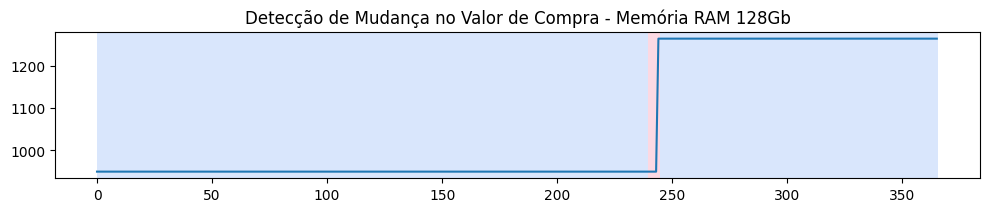

In [81]:
# Produto - Memória RAM 128Gb
produto_df = df[df['NOME_PRODUTO'] == 'Memória RAM 128Gb']
serie = produto_df.groupby(df['DATA_COMPRA'].dt.to_period('D'))['VALOR_COMPRA'].mean().dropna().values

# Algoritmo de detecção de mudança
model = "l2"  # mudança na média
algo = rpt.Pelt(model=model).fit(serie)
result = algo.predict(pen=5)  # penalidade controla sensibilidade

# Visualizar
rpt.display(serie, result)
plt.title('Detecção de Mudança no Valor de Compra - Memória RAM 128Gb')
plt.show()

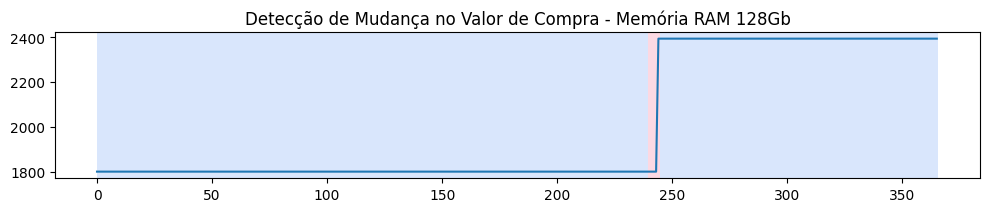

In [82]:
# Produto - Memória RAM 256Gb
produto_df = df[df['NOME_PRODUTO'] == 'Memória RAM 256Gb']
serie = produto_df.groupby(df['DATA_COMPRA'].dt.to_period('D'))['VALOR_COMPRA'].mean().dropna().values

# Algoritmo de detecção de mudança
model = "l2"  # mudança na média
algo = rpt.Pelt(model=model).fit(serie)
result = algo.predict(pen=5)  # penalidade controla sensibilidade

# Visualizar
rpt.display(serie, result)
plt.title('Detecção de Mudança no Valor de Compra - Memória RAM 128Gb')
plt.show()

7. Análise do Mix de Produtos

In [83]:
# Agora vamos ver o percentual de aumento dos produtos
media_mes = df.groupby(df['DATA_COMPRA'].dt.to_period('M'))['VALOR_COMPRA'].mean()
variacao = media_mes.pct_change()

# Identificar variações > 20% como potenciais mudanças
mudancas = variacao[variacao.abs() > 0.2]
print(mudancas)

DATA_COMPRA
2024-09    0.325666
Freq: M, Name: VALOR_COMPRA, dtype: float64


In [84]:
# Converter datas e criar colunas auxiliares
#df['DATA_COMPRA'] = pd.to_datetime(df['DATA_COMPRA'])
df['MES'] = df['DATA_COMPRA'].dt.month
df['PERIODO'] = df['MES'].apply(lambda x: 'Antes Set/24' if x < 9 else 'Após Set/24')

In [85]:
# Resumo por período
resumo_periodo = df.groupby('PERIODO').agg({
    'VALOR_COMPRA': 'mean',
    'VALOR_VENDA': 'mean',
    'QT_VENDA': 'mean',
    'TOTAL_VENDA': 'sum',
    'TOTAL_LUCRO': 'sum'
}).reset_index()
resumo_periodo

,PERIODO,VALOR_COMPRA,VALOR_VENDA,QT_VENDA,TOTAL_VENDA,TOTAL_LUCRO
0,Antes Set/24,765.461853,1263.012058,5.517291,91726998.0,36134878.0
1,Após Set/24,1019.036047,1681.410472,3.276241,36109026.7,14224781.1


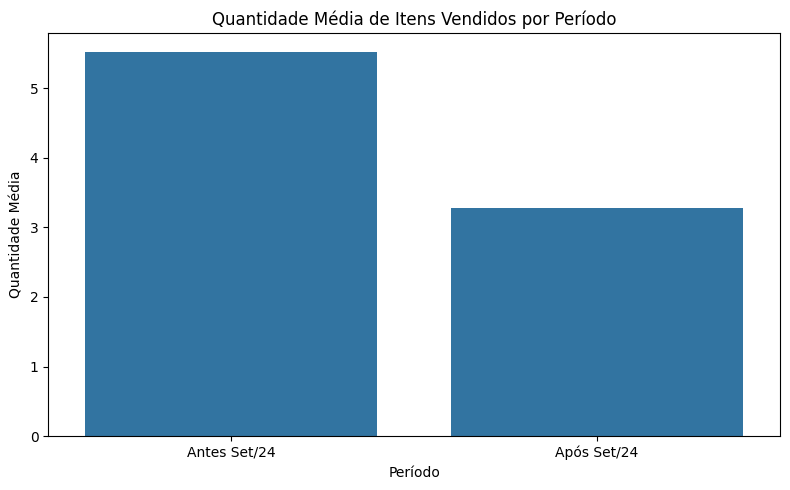

In [86]:
# Gráfico: Quantidade média de itens vendidos
plt.figure(figsize=(8, 5))
sns.barplot(data=resumo_periodo, x='PERIODO', y='QT_VENDA')
plt.title('Quantidade Média de Itens Vendidos por Período')
plt.ylabel('Quantidade Média')
plt.xlabel('Período')
plt.tight_layout()
plt.show()

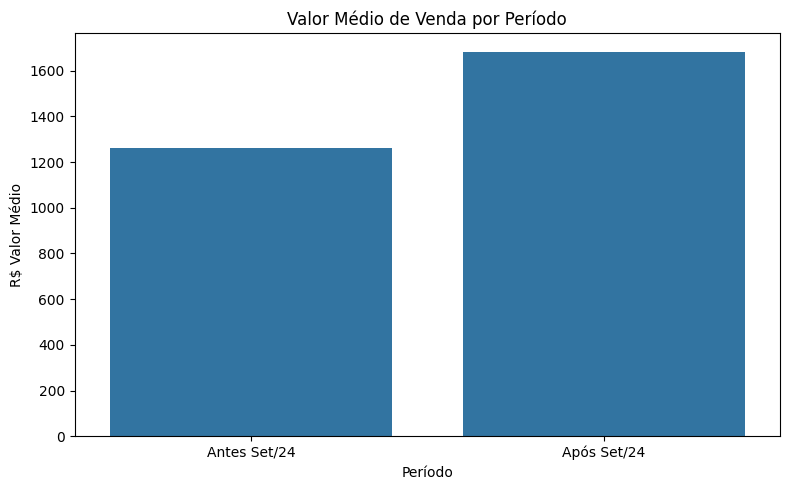

In [87]:
# Gráfico: Valor médio de venda
plt.figure(figsize=(8, 5))
sns.barplot(data=resumo_periodo, x='PERIODO', y='VALOR_VENDA')
plt.title('Valor Médio de Venda por Período')
plt.ylabel('R$ Valor Médio')
plt.xlabel('Período')
plt.tight_layout()
plt.show()

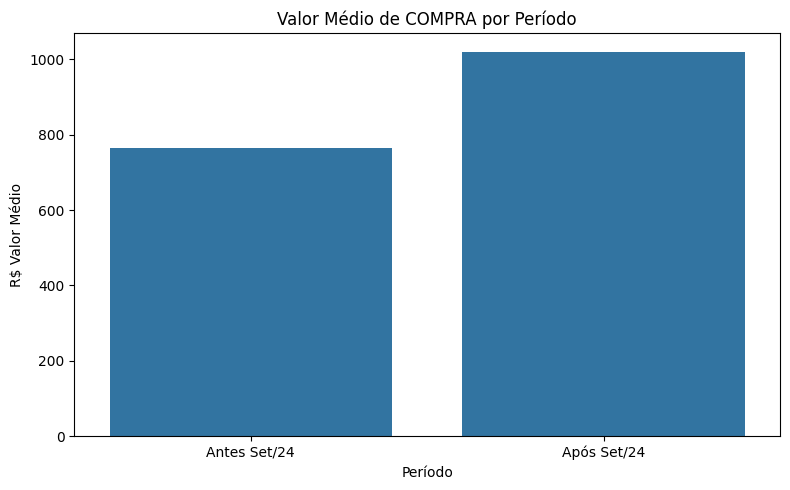

In [88]:
# Gráfico: Valor médio de venda
plt.figure(figsize=(8, 5))
sns.barplot(data=resumo_periodo, x='PERIODO', y='VALOR_COMPRA')
plt.title('Valor Médio de COMPRA por Período')
plt.ylabel('R$ Valor Médio')
plt.xlabel('Período')
plt.tight_layout()
plt.show()

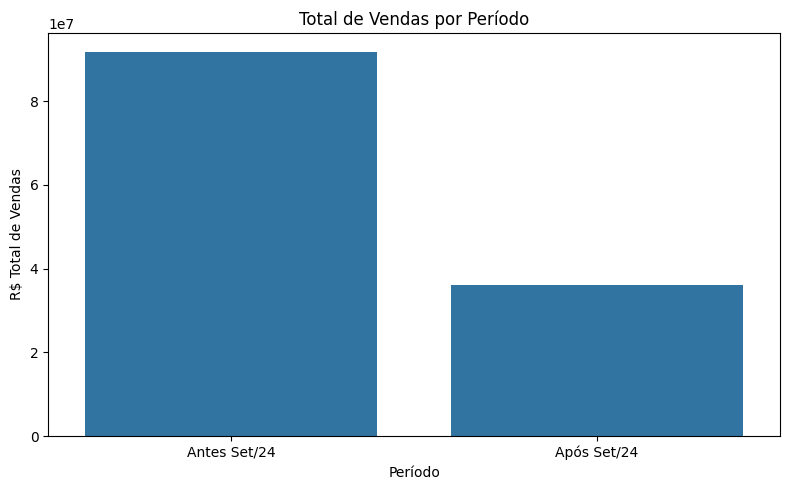

In [89]:
# Gráfico: Total de vendas
plt.figure(figsize=(8, 5))
sns.barplot(data=resumo_periodo, x='PERIODO', y='TOTAL_VENDA')
plt.title('Total de Vendas por Período')
plt.ylabel('R$ Total de Vendas')
plt.xlabel('Período')
plt.tight_layout()
plt.show()

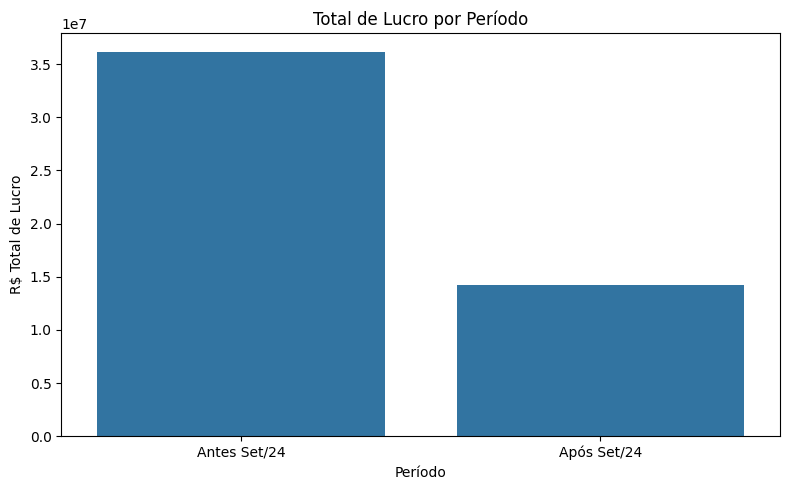

In [90]:
# Gráfico: Total de lucro
plt.figure(figsize=(8, 5))
sns.barplot(data=resumo_periodo, x='PERIODO', y='TOTAL_LUCRO')
plt.title('Total de Lucro por Período')
plt.ylabel('R$ Total de Lucro')
plt.xlabel('Período')
plt.tight_layout()
plt.show()

#Conclusão:
### Os resultados evidenciam uma alteração no mix de vendas, caracterizada pelo aumento na participação de determinados produtos no volume total comercializado. Contudo, observou-se que as margens de contribuição permaneceram inalteradas, o que resultou em um aumento relativo no preço médio percebido. Esse fator pode ter impactado negativamente a demanda, levando à redução no volume de compras por parte dos clientes e, consequentemente, à queda no faturamento.

#Recomendações:
### Diante dos achados, recomenda-se a revisão do mix de produtos, com foco no equilíbrio entre volume e margem. Avaliar estratégias de precificação, incluindo possíveis ajustes ou ações promocionais para aumentar a atratividade dos produtos. Adicionalmente, sugere-se o monitoramento contínuo do comportamento de compra e do ticket médio, a fim de identificar rapidamente variações que possam impactar o desempenho das vendas e apoiar a tomada de decisão estratégica.